<a href="https://colab.research.google.com/github/vinay0145/-Data-Science-Capstone-Project-/blob/main/Banking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Python Data Analysis Code

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Load Data

In [14]:
df = pd.read_excel("bank_dummy_dataset.xlsx")
print(df.head())

   customer_id  age gender  income  account_balance  loan_amount loan_status  \
0            1   59      F   20967            42415        21500    Rejected   
1            2   58      M   32262            40584        28088    Approved   
2            3   30      F   76064            37459         7007    Rejected   
3            4   52      M   40647            13047        35991    Rejected   
4            5   41      M   51973             2698        25623    Approved   

   credit_score       city  
0           411    Chennai  
1           602  Bangalore  
2           614      Delhi  
3           459  Hyderabad  
4           714  Hyderabad  


In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      1000 non-null   int64 
 1   age              1000 non-null   int64 
 2   gender           1000 non-null   object
 3   income           1000 non-null   int64 
 4   account_balance  1000 non-null   int64 
 5   loan_amount      1000 non-null   int64 
 6   loan_status      1000 non-null   object
 7   credit_score     1000 non-null   int64 
 8   city             1000 non-null   object
dtypes: int64(6), object(3)
memory usage: 70.4+ KB
None
       customer_id          age        income  account_balance   loan_amount  \
count  1000.000000  1000.000000   1000.000000      1000.000000   1000.000000   
mean    500.500000    40.767000  47485.144000     26511.565000  22145.406000   
std     288.819436    11.634951  18654.136898     14102.141374  10157.152138   
min       1.000000    21

In [21]:
print(df.isnull().sum())

customer_id           0
age                   0
gender             1000
income                0
account_balance       0
loan_amount           0
loan_status        1000
credit_score          0
city                  0
dtype: int64


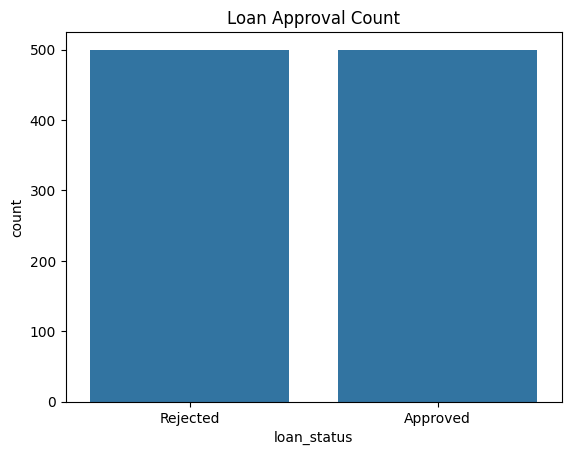

In [8]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Approval Count")
plt.show()

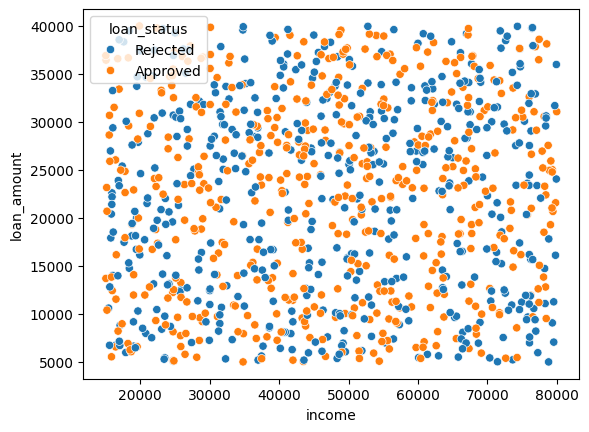

In [9]:
sns.scatterplot(x='income', y='loan_amount', hue='loan_status', data=df)
plt.show()

In [ ]:
# Check data
# Reload df to ensure it's not empty from previous errors
df = pd.read_excel("bank_dummy_dataset.xlsx")

print(df.shape)
print(df.head())

# Handle missing values
# Address FutureWarning by using .ffill() directly
df.ffill(inplace=True)

# Convert only if needed
if df['gender'].dtype == 'object':
    df['gender'] = df['gender'].str.strip().str.upper().map({'M':1, 'F':0})

if df['loan_status'].dtype == 'object':
    df['loan_status'] = df['loan_status'].str.strip().str.capitalize().map({'Approved':1, 'Rejected':0})

# Features & Target
X = df[['age','income','account_balance','credit_score']]
y = df['loan_status']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, solver='liblinear')

model.fit(X_train, y_train)

print("✅ Model trained successfully")